# Donut fine-tuning on CORD v2

End-to-end notebook: loads `naver-clova-ix/donut-base`, fine-tunes on `naver-clova-ix/cord-v2`, and saves the trained model.

Adds light training-time image augmentation (brightness / contrast / tiny rotation) so the same images contribute more signal across epochs.

**Designed for Lightning AI Studio** (single GPU, ~24 GB VRAM e.g. L4/A10). Adjust `IMAGE_SIZE` or `EPOCHS` in the config cell if you have a smaller/larger GPU.

Expected runtime: ~45 min on L4 / ~25 min on A100 for 5 epochs.

## 1. Setup

In [1]:
%pip install -q "transformers==4.44.2" "datasets==2.20.0" "accelerate==0.34.2" "protobuf>=3.20" sentencepiece pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import random
import re
from typing import Any, Callable

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageEnhance
from datasets import load_dataset
from transformers import (
    DonutProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

print("torch:", torch.__version__)
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("device: CPU (training will be very slow)")

torch: 2.12.0+cu130
device: NVIDIA L40S
bf16 supported: True


In [3]:
# Each spec: how to load one dataset and how to extract a gt_parse dict from
# its ground_truth column. Add more entries to mix in additional datasets.
DATASET_SPECS = [
    {
        "name": "naver-clova-ix/cord-v2",
        "train_split": "train",
        "val_split": "validation",
        "image_col": "image",
        "gt_col": "ground_truth",
        "gt_parser": lambda gt: json.loads(gt)["gt_parse"],
        "required": True,
    },
]

class Cfg:
    BASE_MODEL = "naver-clova-ix/donut-base"
    TASK_TOKEN = "<s_cord-v2>"
    IMAGE_SIZE = [1280, 960]  # [height, width]
    MAX_LENGTH = 768           # decoder cap
    OUTPUT_DIR = "./donut-cord-finetuned"
    EPOCHS = 6
    LR = 3e-5
    PER_DEVICE_BATCH = 1
    GRAD_ACC = 4               # effective batch = 4
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    SEED = 42
    USE_AUGMENT = True         # light brightness/contrast/rotation aug

set_seed(Cfg.SEED)
os.makedirs(Cfg.OUTPUT_DIR, exist_ok=True)
print("output dir:", Cfg.OUTPUT_DIR)

output dir: ./donut-cord-finetuned


## 2. Load datasets

Each dataset is loaded independently. Optional ones (`required=False`) that fail to download are skipped with a warning so the notebook keeps running with whatever it has.

In [4]:
loaded_specs = []  # list of (spec, train_split, val_split)

for spec in DATASET_SPECS:
    try:
        ds = load_dataset(spec["name"])
        train_split = ds[spec["train_split"]]
        val_split = ds[spec["val_split"]] if spec["val_split"] in ds else None
        loaded_specs.append((spec, train_split, val_split))
        print(
            f"loaded {spec['name']}: train={len(train_split)}"
            f" val={len(val_split) if val_split else 0}"
        )
    except Exception as exc:
        if spec["required"]:
            raise
        print(f"skipping optional dataset {spec['name']}: {exc}")

assert loaded_specs, "no datasets loaded"
total_train = sum(len(t) for _, t, _ in loaded_specs)
total_val = sum(len(v) for _, _, v in loaded_specs if v is not None)
print(f"\ncombined train: {total_train}  val: {total_val}")

loaded naver-clova-ix/cord-v2: train=800 val=100

combined train: 800  val: 100


In [5]:
# Peek at one example per loaded dataset to confirm the parser works.
for spec, train_split, _ in loaded_specs:
    print(f"\n=== {spec['name']} ===")
    sample = train_split[0]
    gt = spec["gt_parser"](sample[spec["gt_col"]])
    print(json.dumps(gt, indent=2, ensure_ascii=False)[:400])
    print("image size:", sample[spec["image_col"]].size)


=== naver-clova-ix/cord-v2 ===
{
  "menu": [
    {
      "nm": "Nasi Campur Bali",
      "cnt": "1 x",
      "price": "75,000"
    },
    {
      "nm": "Bbk Bengil Nasi",
      "cnt": "1 x",
      "price": "125,000"
    },
    {
      "nm": "MilkShake Starwb",
      "cnt": "1 x",
      "price": "37,000"
    },
    {
      "nm": "Ice Lemon Tea",
      "cnt": "1 x",
      "price": "24,000"
    },
    {
      "nm": "Nasi Ayam Dewa
image size: (864, 1296)


## 3. Model + processor

We resize the Donut encoder to a smaller image (1280×960) to fit a single 24 GB GPU and cap the decoder at 1024 tokens (room for invoice-sized parses).

In [6]:
# use_fast=False forces the slow (sentencepiece) tokenizer and avoids the
# slow->fast conversion that needs the protobuf library.
processor = DonutProcessor.from_pretrained(Cfg.BASE_MODEL, use_fast=False)
model = VisionEncoderDecoderModel.from_pretrained(Cfg.BASE_MODEL)

processor.image_processor.size = {"height": Cfg.IMAGE_SIZE[0], "width": Cfg.IMAGE_SIZE[1]}
processor.image_processor.do_align_long_axis = False
model.config.encoder.image_size = Cfg.IMAGE_SIZE
model.config.decoder.max_length = Cfg.MAX_LENGTH

print("image size:", processor.image_processor.size)
print("decoder max_length:", model.config.decoder.max_length)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


image size: {'height': 1280, 'width': 960}
decoder max_length: 768


## 4. JSON ↔ token conversion

Donut consumes a target sequence built from XML-like tags wrapping the structured fields:
```
<s_receipt><s_menu><s_nm>Latte</s_nm><s_price>9000</s_price></s_menu>...</s>
```
We walk every loaded training split once to collect every `<s_KEY>` / `</s_KEY>` pair, add them to the tokenizer, and resize the decoder embeddings — so the vocab covers fields from all datasets, not just CORD.

In [7]:
def json2token(obj: Any, sort_keys: bool = True) -> str:
    if isinstance(obj, dict):
        if len(obj) == 1 and "text_sequence" in obj:
            return obj["text_sequence"]
        keys = sorted(obj.keys()) if sort_keys else list(obj.keys())
        out = ""
        for k in keys:
            out += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return out
    if isinstance(obj, list):
        return "<sep/>".join(json2token(x, sort_keys) for x in obj)
    return str(obj)


def collect_keys(obj: Any, out: set) -> None:
    if isinstance(obj, dict):
        for k, v in obj.items():
            out.add(k)
            collect_keys(v, out)
    elif isinstance(obj, list):
        for x in obj:
            collect_keys(x, out)


def safe_parse(spec, gt_value):
    """Run a spec's gt_parser, returning None on failure so the example is skipped."""
    try:
        parsed = spec["gt_parser"](gt_value)
        if isinstance(parsed, dict):
            return parsed
        return None
    except Exception:
        return None

In [8]:
all_keys: set = set()
kept_per_dataset = {}
for spec, train_split, _ in loaded_specs:
    kept = 0
    for gt_value in train_split[spec["gt_col"]]:
        parsed = safe_parse(spec, gt_value)
        if parsed is not None:
            collect_keys(parsed, all_keys)
            kept += 1
    kept_per_dataset[spec["name"]] = kept
    print(f"{spec['name']}: parsed {kept}/{len(train_split)} train examples")

print(f"\ndiscovered {len(all_keys)} unique keys across all datasets")
print("sample keys:", sorted(all_keys)[:20])

# Special tokens (task start + JSON list separator)
processor.tokenizer.add_special_tokens({"additional_special_tokens": [Cfg.TASK_TOKEN]})

# Field-tag tokens — sorted for reproducibility
field_tokens = []
for k in sorted(all_keys):
    field_tokens.append(f"<s_{k}>")
    field_tokens.append(f"</s_{k}>")
field_tokens.append("<sep/>")
added = processor.tokenizer.add_tokens(field_tokens)
model.decoder.resize_token_embeddings(len(processor.tokenizer))

# Wire the task-start and pad tokens into the model config so generation works.
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(Cfg.TASK_TOKEN)
model.config.eos_token_id = processor.tokenizer.eos_token_id

print(f"\nvocab size after add: {len(processor.tokenizer)} (+{added} field tokens)")
print("decoder_start_token_id:", model.config.decoder_start_token_id)

naver-clova-ix/cord-v2: parsed 800/800 train examples

discovered 27 unique keys across all datasets
sample keys: ['cashprice', 'changeprice', 'cnt', 'creditcardprice', 'discount_price', 'discountprice', 'emoneyprice', 'etc', 'itemsubtotal', 'menu', 'menuqty_cnt', 'menutype_cnt', 'nm', 'num', 'othersvc_price', 'price', 'service_price', 'sub', 'sub_total', 'subtotal_price']

vocab size after add: 57580 (+54 field tokens)
decoder_start_token_id: 57525


In [9]:
# Sanity check: convert one sample to its target sequence and confirm it fits.
first_spec, first_train, _ = loaded_specs[0]
demo_parse = safe_parse(first_spec, first_train[0][first_spec["gt_col"]])
demo = json2token(demo_parse)
print("target sequence (first 400 chars):")
print(demo[:400])
ids = processor.tokenizer(demo, add_special_tokens=False).input_ids
print("\nlen(target tokens):", len(ids))
assert len(ids) < Cfg.MAX_LENGTH, "target longer than MAX_LENGTH — raise the cap"

target sequence (first 400 chars):
<s_menu><s_cnt>1 x</s_cnt><s_nm>Nasi Campur Bali</s_nm><s_price>75,000</s_price><sep/><s_cnt>1 x</s_cnt><s_nm>Bbk Bengil Nasi</s_nm><s_price>125,000</s_price><sep/><s_cnt>1 x</s_cnt><s_nm>MilkShake Starwb</s_nm><s_price>37,000</s_price><sep/><s_cnt>1 x</s_cnt><s_nm>Ice Lemon Tea</s_nm><s_price>24,000</s_price><sep/><s_cnt>1 x</s_cnt><s_nm>Nasi Ayam Dewata</s_nm><s_price>70,000</s_price><sep/><s_cn

len(target tokens): 373


## 5. PyTorch dataset

`MultiDonutDataset` flattens every loaded dataset split into one indexable view, pre-computes the target sequences (so we don't re-parse JSON each step), and applies light brightness/contrast/rotation augmentation when training.

In [10]:
def light_augment(image: Image.Image) -> Image.Image:
    """Mild perturbations that keep the receipt readable."""
    if random.random() < 0.5:
        image = ImageEnhance.Brightness(image).enhance(0.85 + random.random() * 0.3)
    if random.random() < 0.5:
        image = ImageEnhance.Contrast(image).enhance(0.85 + random.random() * 0.3)
    if random.random() < 0.3:
        angle = random.uniform(-3.0, 3.0)
        image = image.rotate(
            angle, resample=Image.BICUBIC, fillcolor=(255, 255, 255)
        )
    return image


class MultiDonutDataset(Dataset):
    def __init__(self, specs_with_splits, processor, max_length, task_token, augment=False):
        self.processor = processor
        self.max_length = max_length
        self.task_token = task_token
        self.augment = augment
        self.eos = processor.tokenizer.eos_token

        # (spec, split, local_idx) tuples for every kept example.
        self.entries = []
        self.targets = []
        for spec, split in specs_with_splits:
            gt_values = split[spec["gt_col"]]
            for i, gt_value in enumerate(gt_values):
                parsed = safe_parse(spec, gt_value)
                if parsed is None:
                    continue
                self.entries.append((spec, split, i))
                self.targets.append(task_token + json2token(parsed) + self.eos)

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        spec, split, local_idx = self.entries[idx]
        image = split[local_idx][spec["image_col"]]
        if image.mode != "RGB":
            image = image.convert("RGB")
        if self.augment:
            image = light_augment(image)

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        target = self.targets[idx]
        labels = self.processor.tokenizer(
            target,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
            add_special_tokens=False,
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}

In [11]:
train_specs = [(spec, train) for spec, train, _ in loaded_specs]
val_specs = [(spec, val) for spec, _, val in loaded_specs if val is not None]

train_ds = MultiDonutDataset(
    train_specs, processor, Cfg.MAX_LENGTH, Cfg.TASK_TOKEN, augment=Cfg.USE_AUGMENT
)
val_ds = MultiDonutDataset(
    val_specs, processor, Cfg.MAX_LENGTH, Cfg.TASK_TOKEN, augment=False
)
print("train:", len(train_ds), "val:", len(val_ds))

_item = train_ds[0]
print("pixel_values shape:", tuple(_item["pixel_values"].shape))
print("labels shape:", tuple(_item["labels"].shape))
print("first non-ignored target tokens:")
_labels = _item["labels"].clone()
_labels[_labels == -100] = processor.tokenizer.pad_token_id
print(processor.tokenizer.decode(_labels[:50]))

train: 800 val: 100
pixel_values shape: (3, 1280, 960)
labels shape: (768,)
first non-ignored target tokens:
<s_cord-v2> <s_menu> <s_cnt> 1 x </s_cnt> <s_nm> Nasi Campur Bali </s_nm> <s_price> 75,000 </s_price> <sep/> <s_cnt> 1 x </s_cnt> <s_nm> Bbk Bengil Nasi </s_nm> <s_price> 125,000 </s_price> <sep/> <s_cnt> 1 x </s_cnt> <s_nm> MilkShake Starwb </s_nm> <s_price> 37,000


## 6. Training

- Effective batch = 1 × 4 grad-accum = 4.
- bf16 on Ampere+, fp16 otherwise.
- Gradient checkpointing on (cuts encoder memory ~40%).

In [12]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

args = Seq2SeqTrainingArguments(
    output_dir=Cfg.OUTPUT_DIR,
    num_train_epochs=Cfg.EPOCHS,
    learning_rate=Cfg.LR,
    per_device_train_batch_size=Cfg.PER_DEVICE_BATCH,
    per_device_eval_batch_size=Cfg.PER_DEVICE_BATCH,
    gradient_accumulation_steps=Cfg.GRAD_ACC,
    weight_decay=Cfg.WEIGHT_DECAY,
    warmup_ratio=Cfg.WARMUP_RATIO,
    bf16=use_bf16,
    fp16=use_fp16,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    eval_strategy="epoch" if len(val_ds) > 0 else "no",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=len(val_ds) > 0,
    metric_for_best_model="eval_loss" if len(val_ds) > 0 else None,
    greater_is_better=False,
    logging_steps=20,
    predict_with_generate=False,
    remove_unused_columns=False,
    dataloader_num_workers=2,
    report_to=[],
    seed=Cfg.SEED,
)
print("bf16:", use_bf16, " fp16:", use_fp16)

bf16: True  fp16: False


In [13]:
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds if len(val_ds) > 0 else None,
)

train_result = trainer.train()
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)

`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.687900,0.428923
2,0.263100,0.231363
3,0.205800,0.172101
4,0.106700,0.153885
5,0.103800,0.146334
6,0.086900,0.149762


There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


***** train metrics *****
  epoch                    =           6.0
  total_flos               = 13978384365GF
  train_loss               =         0.823
  train_runtime            =    0:15:27.57
  train_samples_per_second =         5.175
  train_steps_per_second   =         1.294


## 7. Save final model + processor

In [14]:
final_dir = os.path.join(Cfg.OUTPUT_DIR, "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print("saved to", final_dir)

saved to ./donut-cord-finetuned/final


## 8. Quick inference demo

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()
model.to(device)

# Pull a sample from the first dataset's validation split.
_demo_spec, _, _demo_val = loaded_specs[0]
assert _demo_val is not None, "no validation split on the primary dataset"
test_sample = _demo_val[0]
image = test_sample[_demo_spec["image_col"]].convert("RGB")
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

decoder_input_ids = processor.tokenizer(
    Cfg.TASK_TOKEN, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

with torch.inference_mode():
    out = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=Cfg.MAX_LENGTH,
        early_stopping=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=1,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )

seq = processor.batch_decode(out.sequences)[0]
seq = seq.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
seq = re.sub(r"<.*?>", "", seq, count=1).strip()  # strip the leading task token
parsed = processor.token2json(seq)

print("--- prediction ---")
print(json.dumps(parsed, indent=2, ensure_ascii=False)[:1500])
print("\n--- ground truth ---")
gt_demo = _demo_spec["gt_parser"](test_sample[_demo_spec["gt_col"]])
print(json.dumps(gt_demo, indent=2, ensure_ascii=False)[:1500])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


--- prediction ---
{
  "menu": [
    {
      "cnt": "1",
      "nm": "REAL GANACHE",
      "price": "16,500"
    },
    {
      "cnt": "1",
      "nm": "EGG TART",
      "price": "13,000"
    },
    {
      "cnt": "1",
      "nm": "PIZZA TOAST",
      "price": "16,000"
    }
  ],
  "total": {
    "cashprice": "50,000",
    "changeprice": "4,500",
    "total_price": "45,500"
  }
}

--- ground truth ---
{
  "menu": [
    {
      "nm": "REAL GANACHE",
      "cnt": "1",
      "price": "16,500"
    },
    {
      "nm": "EGG TART",
      "cnt": "1",
      "price": "13,000"
    },
    {
      "nm": "PIZZA TOAST",
      "cnt": "1",
      "price": "16,000"
    }
  ],
  "total": {
    "total_price": "45,500",
    "cashprice": "50,000",
    "changeprice": "4,500"
  }
}


## 9. Evaluation on the full validation set

Computes the metrics you'll need for the report:
- **Exact match accuracy** — fraction of receipts where the prediction equals the ground truth.
- **Field-level micro / macro F1** — multiset comparison of `(path, value)` pairs (list order ignored, the way Donut's original CORD evaluation does it).
- **Normalized Tree Edit Distance (nTED)** — Donut's canonical metric. Lower is better. Reported alongside `TED_accuracy = 1 − nTED`.
- **Latency** — mean / p50 / p95 per-receipt inference time.
- **Per-field breakdown** — P/R/F1 grouped by top-level key (`menu`, `sub_total`, `total`, ...).

In [16]:
%pip install -q editdistance zss matplotlib

import editdistance
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from zss import Node, simple_distance
from IPython.display import display

# If the kernel was restarted between training and eval, reload the
# fine-tuned model from disk.
try:
    model
    processor
except NameError:
    processor = DonutProcessor.from_pretrained(final_dir, use_fast=False)
    model = VisionEncoderDecoderModel.from_pretrained(final_dir)
    model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


def flatten(obj, prefix=""):
    """Yield (path, str_value) pairs. Lists are flattened index-free so item order
    doesn't penalise the model — comparison is multiset-based."""
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            p = f"{prefix}.{k}" if prefix else k
            out.extend(flatten(v, p))
    elif isinstance(obj, list):
        for x in obj:
            out.extend(flatten(x, prefix))
    else:
        out.append((prefix, str(obj).strip()))
    return out


def field_prf(gt, pred):
    """Per-receipt precision/recall/F1 at the multiset (path, value) level."""
    g = Counter(flatten(gt))
    p = Counter(flatten(pred))
    tp = sum((g & p).values())
    fp = sum((p - g).values())
    fn = sum((g - p).values())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return tp, fp, fn, prec, rec, f1


def to_zss_tree(obj, label="root"):
    """Convert nested JSON into a zss Node tree for tree edit distance."""
    node = Node(str(label))
    if isinstance(obj, dict):
        for k in sorted(obj.keys()):
            node.addkid(to_zss_tree(obj[k], k))
    elif isinstance(obj, list):
        for i, x in enumerate(obj):
            node.addkid(to_zss_tree(x, f"[{i}]"))
    else:
        node.addkid(Node(str(obj)))
    return node


def tree_size(n):
    return 1 + sum(tree_size(c) for c in n.children)


def normalized_ted(gt, pred):
    """Donut's canonical metric: TED / max(|gt|, |pred|).  Lower is better."""
    g = to_zss_tree(gt)
    p = to_zss_tree(pred)
    return simple_distance(g, p) / max(tree_size(g), tree_size(p))


print("metrics helpers ready")

Note: you may need to restart the kernel to use updated packages.
metrics helpers ready


In [17]:
import time
from tqdm.auto import tqdm

all_preds = []
all_gts = []
latencies_ms = []

decoder_start_ids = processor.tokenizer(
    Cfg.TASK_TOKEN, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

for spec, split, local_idx in tqdm(val_ds.entries, desc="generating"):
    sample = split[local_idx]
    image = sample[spec["image_col"]]
    if image.mode != "RGB":
        image = image.convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    t0 = time.perf_counter()
    with torch.inference_mode():
        out = model.generate(
            pixel_values,
            decoder_input_ids=decoder_start_ids,
            max_length=Cfg.MAX_LENGTH,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )
    latencies_ms.append((time.perf_counter() - t0) * 1000)

    seq = processor.batch_decode(out.sequences)[0]
    seq = seq.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    seq = re.sub(r"<.*?>", "", seq, count=1).strip()
    try:
        pred = processor.token2json(seq)
    except Exception:
        pred = {}
    if not isinstance(pred, dict):
        pred = {}
    all_preds.append(pred)

    gt = safe_parse(spec, sample[spec["gt_col"]])
    all_gts.append(gt or {})

print(f"\n{len(all_preds)} validation predictions")
print(
    f"avg latency: {sum(latencies_ms)/len(latencies_ms):.0f} ms"
    f"  (min {min(latencies_ms):.0f} / max {max(latencies_ms):.0f})"
)

generating:   0%|          | 0/100 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(



100 validation predictions
avg latency: 373 ms  (min 171 / max 1177)


In [18]:
exact_correct = sum(1 for g, p in zip(all_gts, all_preds) if g == p)
exact_match_acc = exact_correct / len(all_gts)

# Field-level micro-F1 (aggregate TP/FP/FN over all receipts)
micro_tp = micro_fp = micro_fn = 0
per_receipt_f1 = []
for g, p in zip(all_gts, all_preds):
    tp, fp, fn, _, _, f1 = field_prf(g, p)
    micro_tp += tp
    micro_fp += fp
    micro_fn += fn
    per_receipt_f1.append(f1)

micro_p = micro_tp / (micro_tp + micro_fp) if micro_tp + micro_fp else 0.0
micro_r = micro_tp / (micro_tp + micro_fn) if micro_tp + micro_fn else 0.0
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if micro_p + micro_r else 0.0
macro_f1 = sum(per_receipt_f1) / len(per_receipt_f1)

# Normalized Tree Edit Distance — Donut's canonical metric
nteds = [normalized_ted(g, p) for g, p in zip(all_gts, all_preds)]
mean_nted = sum(nteds) / len(nteds)
ted_acc = 1 - mean_nted

sorted_lat = sorted(latencies_ms)
OVERALL_METRICS = {
    "validation_samples": len(all_gts),
    "exact_match_accuracy": round(exact_match_acc, 4),
    "field_micro_precision": round(micro_p, 4),
    "field_micro_recall": round(micro_r, 4),
    "field_micro_f1": round(micro_f1, 4),
    "field_macro_f1": round(macro_f1, 4),
    "mean_normalized_TED": round(mean_nted, 4),
    "TED_accuracy": round(ted_acc, 4),
    "avg_latency_ms": round(sum(latencies_ms) / len(latencies_ms), 1),
    "p50_latency_ms": round(sorted_lat[len(sorted_lat) // 2], 1),
    "p95_latency_ms": round(sorted_lat[int(len(sorted_lat) * 0.95)], 1),
}

print(json.dumps(OVERALL_METRICS, indent=2))

{
  "validation_samples": 100,
  "exact_match_accuracy": 0.39,
  "field_micro_precision": 0.8304,
  "field_micro_recall": 0.8154,
  "field_micro_f1": 0.8228,
  "field_macro_f1": 0.8471,
  "mean_normalized_TED": 0.4776,
  "TED_accuracy": 0.5224,
  "avg_latency_ms": 372.6,
  "p50_latency_ms": 340.1,
  "p95_latency_ms": 713.8
}


In [19]:
field_tp = defaultdict(int)
field_fp = defaultdict(int)
field_fn = defaultdict(int)


def top_level(path: str) -> str:
    return path.split(".")[0]


for g, p in zip(all_gts, all_preds):
    g_items = Counter(flatten(g))
    p_items = Counter(flatten(p))
    for item, n in (g_items & p_items).items():
        field_tp[top_level(item[0])] += n
    for item, n in (p_items - g_items).items():
        field_fp[top_level(item[0])] += n
    for item, n in (g_items - p_items).items():
        field_fn[top_level(item[0])] += n

per_field = {}
print(f"{'field':<20s} {'P':>7s} {'R':>7s} {'F1':>7s} {'support':>8s}")
print("-" * 55)
for k in sorted(set(field_tp) | set(field_fp) | set(field_fn)):
    tp_, fp_, fn_ = field_tp[k], field_fp[k], field_fn[k]
    p = tp_ / (tp_ + fp_) if tp_ + fp_ else 0
    r = tp_ / (tp_ + fn_) if tp_ + fn_ else 0
    f1 = 2 * p * r / (p + r) if p + r else 0
    per_field[k] = {
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f1": round(f1, 4),
        "support": tp_ + fn_,
    }
    print(f"{k:<20s} {p:7.3f} {r:7.3f} {f1:7.3f} {tp_+fn_:8d}")

OVERALL_METRICS["per_field"] = per_field

field                      P       R      F1  support
-------------------------------------------------------
menu                   0.792   0.782   0.787      806
sub_total              0.891   0.844   0.867      135
total                  0.912   0.899   0.906      278


## 10. Training curves (loss over steps)

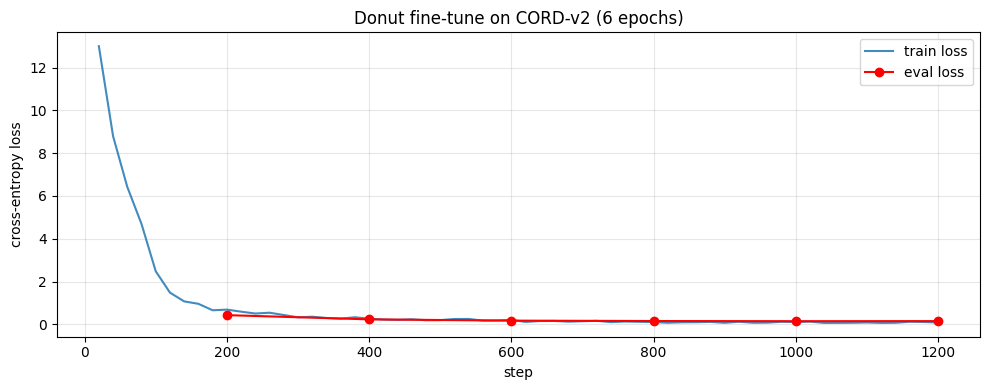

saved ./donut-cord-finetuned/loss_curve.png


In [20]:
log_history = trainer.state.log_history

train_pts = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_pts  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]

plt.figure(figsize=(10, 4))
if train_pts:
    xs, ys = zip(*train_pts)
    plt.plot(xs, ys, label="train loss", alpha=0.85)
if eval_pts:
    xs, ys = zip(*eval_pts)
    plt.plot(xs, ys, "ro-", label="eval loss", markersize=6)
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.title(f"Donut fine-tune on CORD-v2 ({Cfg.EPOCHS} epochs)")
plt.legend()
plt.grid(True, alpha=0.3)
curve_path = os.path.join(Cfg.OUTPUT_DIR, "loss_curve.png")
plt.tight_layout()
plt.savefig(curve_path, dpi=120)
plt.show()
print("saved", curve_path)

## 11. Qualitative examples (5 random validation receipts)

sample 81    precision=1.00  recall=1.00  F1=1.00    latency=610ms
--- ground truth ---
{
  "menu": [
    {
      "nm": "SURIMI",
      "cnt": "1",
      "price": "29,091"
    },
    {
      "nm": "CREAMY CHK CLS FTC",
      "cnt": "1",
      "price": "42,727"
    },
    {
      "nm": "MIX 4FUN CHOCOLATE",
      "cnt": "1",
      "price": "19,091"
    },
    {
      "nm": "GREEN ITSODA PITCHER",
      "cnt": "1",
      "price": "60,909"
    },
    {
      "nm": "SC/R GRILLED STEAK",
      "cnt": "1",
      "price": "99,091"
    }
  ],
  "sub_total": {
    "subtotal_price": "250,909",
    "tax_price": "25,091"
  },
  "total": {
    "total_price": "276,000"
  }
}
--- prediction ---
{
  "menu": [
    {
      "cnt": "1",
      "nm": "SURIMI",
      "price": "29,091"
    },
    {
      "cnt": "1",
      "nm": "CREAMY CHK CLS FTC",
      "price": "42,727"
    },
    {
      "cnt": "1",
      "nm": "MIX 4FUN CHOCOLATE",
      "price": "19,091"
    },
    {
      "cnt": "1",
      "nm": "GREEN

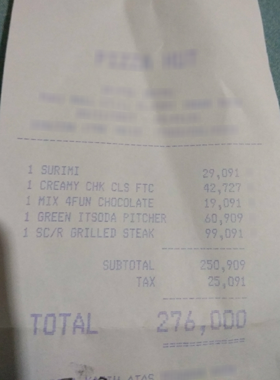

sample 14    precision=0.58  recall=0.58  F1=0.58    latency=355ms
--- ground truth ---
{
  "menu": [
    {
      "nm": "Arem Arem",
      "unitprice": "@ 12.000",
      "cnt": "2 x",
      "price": "24.000"
    },
    {
      "nm": "Kroket",
      "unitprice": "@ 12.000",
      "cnt": "1 x",
      "price": "12.000"
    }
  ],
  "sub_total": {
    "subtotal_price": "Rp 36.000",
    "tax_price": "Rp 3.600"
  },
  "total": {
    "total_price": "Rp 39.600",
    "emoneyprice": "Rp 39.600"
  }
}
--- prediction ---
{
  "menu": [
    {
      "cnt": "2x",
      "nm": "Arem",
      "price": "24.000",
      "unitprice": "@12.000"
    },
    {
      "cnt": "1x",
      "nm": "Kroket",
      "price": "12.000",
      "unitprice": "@12.000"
    }
  ],
  "sub_total": {
    "subtotal_price": "Rp 36.000",
    "tax_price": "Rp 3.600"
  },
  "total": {
    "emoneyprice": "Rp 39.600",
    "total_price": "Rp 39.600"
  }
}


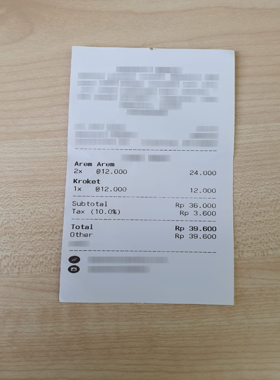

sample 3    precision=0.64  recall=0.64  F1=0.64    latency=392ms
--- ground truth ---
{
  "menu": {
    "nm": "M-Caramel Black Tea",
    "unitprice": "@28,000",
    "cnt": "1X",
    "price": "28,000",
    "sub": [
      {
        "nm": "70%"
      },
      {
        "nm": "Less Ice"
      }
    ]
  },
  "sub_total": {
    "subtotal_price": "28,000",
    "tax_price": "0"
  },
  "total": {
    "total_price": "28,000",
    "cashprice": "28,000",
    "changeprice": "0"
  }
}
--- prediction ---
{
  "menu": [
    {
      "cnt": "1X",
      "price": "28,000",
      "sub": {
        "nm": "70%"
      },
      "unitprice": "28,000"
    },
    {
      "cnt": "1",
      "nm": "Less Ice",
      "unitprice": "@28,000"
    }
  ],
  "sub_total": {
    "subtotal_price": "28,000"
  },
  "total": {
    "cashprice": "28,000",
    "changeprice": "Q -",
    "total_price": "28,000"
  }
}


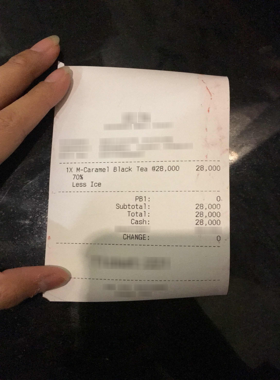

sample 94    precision=0.60  recall=0.55  F1=0.57    latency=320ms
--- ground truth ---
{
  "menu": {
    "nm": "Emily's Shrimp Scampi Fettucine",
    "cnt": "1",
    "price": "69.000"
  },
  "sub_total": {
    "subtotal_price": "69.000",
    "discount_price": "0",
    "service_price": "3.795",
    "etc": [
      "7.280",
      "+25"
    ]
  },
  "total": {
    "total_price": "80.100",
    "total_etc": "80.100",
    "changeprice": "0"
  }
}
--- prediction ---
{
  "menu": {
    "cnt": "1",
    "nm": "Emily's Shrimp Scampi",
    "price": "69.000",
    "sub": {
      "nm": "Fettucine"
    }
  },
  "sub_total": {
    "discount_price": "0",
    "subtotal_price": "69.000",
    "tax_price": "3.795"
  },
  "total": {
    "changeprice": "0",
    "creditcardprice": "80.100",
    "total_price": "80.100"
  }
}


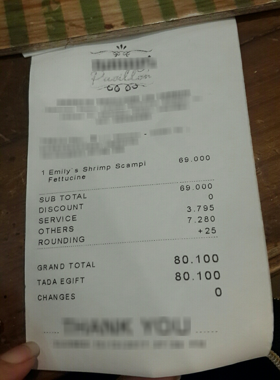

sample 35    precision=1.00  recall=1.00  F1=1.00    latency=552ms
--- ground truth ---
{
  "menu": [
    {
      "nm": "BLACK PEPPER MEATBALL",
      "cnt": "1",
      "price": "76,500"
    },
    {
      "nm": "QUARTO FORMANGGI PASTA",
      "cnt": "1",
      "price": "82,500"
    },
    {
      "nm": "GREEN TEA WITH CRUMBLE",
      "cnt": "1",
      "price": "56,000"
    },
    {
      "nm": "ORIGINAL BREWED TEA",
      "cnt": "2",
      "price": "46,000"
    }
  ],
  "sub_total": {
    "subtotal_price": "261,000",
    "service_price": "15,660",
    "tax_price": "27,666"
  },
  "total": {
    "total_price": "304,326"
  }
}
--- prediction ---
{
  "menu": [
    {
      "cnt": "1",
      "nm": "BLACK PEPPER MEATBALL",
      "price": "76,500"
    },
    {
      "cnt": "1",
      "nm": "QUARTO FORMANGGI PASTA",
      "price": "82,500"
    },
    {
      "cnt": "1",
      "nm": "GREEN TEA WITH CRUMBLE",
      "price": "56,000"
    },
    {
      "cnt": "2",
      "nm": "ORIGINAL BREWED TE

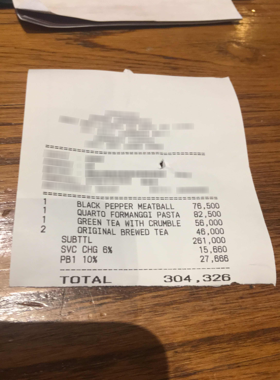

In [21]:
import random as _random

_random.seed(42)
sample_idxs = _random.sample(range(len(all_preds)), k=min(5, len(all_preds)))

for idx in sample_idxs:
    spec, split, local_idx = val_ds.entries[idx]
    image = split[local_idx][spec["image_col"]]
    if image.mode != "RGB":
        image = image.convert("RGB")

    gt = all_gts[idx]
    pred = all_preds[idx]
    _, _, _, p, r, f1 = field_prf(gt, pred)

    print("=" * 70)
    print(f"sample {idx}    precision={p:.2f}  recall={r:.2f}  F1={f1:.2f}    latency={latencies_ms[idx]:.0f}ms")
    print("--- ground truth ---")
    print(json.dumps(gt, indent=2, ensure_ascii=False)[:600])
    print("--- prediction ---")
    print(json.dumps(pred, indent=2, ensure_ascii=False)[:600])
    display(image.resize((280, 380)))

## 12. Persist everything for the report

Saves a single JSON file (`report_data.json`) with the config, full training log history, all metrics, and every (ground-truth, prediction, latency) tuple — drop straight into the report appendix.

In [ ]:
report_path = os.path.join(Cfg.OUTPUT_DIR, "report_data.json")

report = {
    "config": {
        "base_model": Cfg.BASE_MODEL,
        "task_token": Cfg.TASK_TOKEN,
        "image_size": Cfg.IMAGE_SIZE,
        "max_length": Cfg.MAX_LENGTH,
        "epochs": Cfg.EPOCHS,
        "learning_rate": Cfg.LR,
        "effective_batch_size": Cfg.PER_DEVICE_BATCH * Cfg.GRAD_ACC,
        "use_augment": Cfg.USE_AUGMENT,
    },
    "training_log_history": log_history,
    "metrics": OVERALL_METRICS,
    "predictions": [
        {"index": i, "ground_truth": g, "prediction": p, "latency_ms": l}
        for i, (g, p, l) in enumerate(zip(all_gts, all_preds, latencies_ms))
    ],
}

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"saved {report_path}")
print(f"size: {os.path.getsize(report_path) / 1024:.1f} KB")
print(f"\nartifacts in {Cfg.OUTPUT_DIR}:")
for fn in sorted(os.listdir(Cfg.OUTPUT_DIR)):
    full = os.path.join(Cfg.OUTPUT_DIR, fn)
    if os.path.isfile(full):
        print(f"  {fn:<40s}  {os.path.getsize(full) / 1024:7.1f} KB")

saved ./donut-cord-finetuned/report_data.json
size: 127.3 KB

artifacts in ./donut-cord-finetuned:
  all_results.json                              0.2 KB
  loss_curve.png                               38.0 KB
  report_data.json                            127.3 KB
  train_results.json                            0.2 KB


## 13. Test set evaluation — the headline numbers

Validation was used to pick the best checkpoint (`load_best_model_at_end=True`), so its numbers are slightly optimistic. The **test split** (100 receipts the model has never seen during training or selection) is what you cite in the report.

In [23]:
# Pull the test split using the same spec used for training/validation.
_test_spec = loaded_specs[0][0]
test_split = None
try:
    _ds_obj = load_dataset(_test_spec["name"])
    if "test" in _ds_obj:
        test_split = _ds_obj["test"]
    else:
        print(f"no test split (available: {list(_ds_obj.keys())})")
except Exception as e:
    print(f"failed to load test split: {e}")

test_preds, test_gts, test_latencies = [], [], []
if test_split is not None:
    print(f"test split size: {len(test_split)}")
    for i in tqdm(range(len(test_split)), desc="test"):
        sample = test_split[i]
        image = sample[_test_spec["image_col"]]
        if image.mode != "RGB":
            image = image.convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
        t0 = time.perf_counter()
        with torch.inference_mode():
            out = model.generate(
                pixel_values,
                decoder_input_ids=decoder_start_ids,
                max_length=Cfg.MAX_LENGTH,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
                use_cache=True,
                num_beams=1,
                bad_words_ids=[[processor.tokenizer.unk_token_id]],
                return_dict_in_generate=True,
            )
        test_latencies.append((time.perf_counter() - t0) * 1000)
        seq = processor.batch_decode(out.sequences)[0]
        seq = seq.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
        seq = re.sub(r"<.*?>", "", seq, count=1).strip()
        try:
            pred = processor.token2json(seq)
        except Exception:
            pred = {}
        if not isinstance(pred, dict):
            pred = {}
        test_preds.append(pred)
        gt = _test_spec["gt_parser"](sample[_test_spec["gt_col"]])
        test_gts.append(gt if isinstance(gt, dict) else {})
    print(f"\n{len(test_preds)} test predictions, avg latency {sum(test_latencies)/len(test_latencies):.0f}ms")

test split size: 100


test:   0%|          | 0/100 [00:00<?, ?it/s]


100 test predictions, avg latency 387ms


In [24]:
TEST_METRICS = None

if test_split is not None and test_preds:
    test_exact = sum(1 for g, p in zip(test_gts, test_preds) if g == p) / len(test_gts)

    t_tp = t_fp = t_fn = 0
    t_f1s = []
    for g, p in zip(test_gts, test_preds):
        tp, fp, fn, _, _, f1 = field_prf(g, p)
        t_tp += tp; t_fp += fp; t_fn += fn
        t_f1s.append(f1)
    t_p = t_tp / (t_tp + t_fp) if t_tp + t_fp else 0.0
    t_r = t_tp / (t_tp + t_fn) if t_tp + t_fn else 0.0
    t_micro_f1 = 2 * t_p * t_r / (t_p + t_r) if t_p + t_r else 0.0
    t_macro_f1 = sum(t_f1s) / len(t_f1s)

    t_nteds = [normalized_ted(g, p) for g, p in zip(test_gts, test_preds)]
    t_mean_nted = sum(t_nteds) / len(t_nteds)

    t_sorted = sorted(test_latencies)
    TEST_METRICS = {
        "test_samples": len(test_gts),
        "exact_match_accuracy": round(test_exact, 4),
        "field_micro_precision": round(t_p, 4),
        "field_micro_recall": round(t_r, 4),
        "field_micro_f1": round(t_micro_f1, 4),
        "field_macro_f1": round(t_macro_f1, 4),
        "mean_normalized_TED": round(t_mean_nted, 4),
        "TED_accuracy": round(1 - t_mean_nted, 4),
        "avg_latency_ms": round(sum(test_latencies) / len(test_latencies), 1),
        "p50_latency_ms": round(t_sorted[len(t_sorted) // 2], 1),
        "p95_latency_ms": round(t_sorted[int(len(t_sorted) * 0.95)], 1),
    }
    print(json.dumps(TEST_METRICS, indent=2))
else:
    print("(no test predictions — skipping test metrics)")

{
  "test_samples": 100,
  "exact_match_accuracy": 0.29,
  "field_micro_precision": 0.8141,
  "field_micro_recall": 0.7909,
  "field_micro_f1": 0.8023,
  "field_macro_f1": 0.8165,
  "mean_normalized_TED": 0.7015,
  "TED_accuracy": 0.2985,
  "avg_latency_ms": 386.7,
  "p50_latency_ms": 326.1,
  "p95_latency_ms": 852.7
}


## 14. Training dynamics — per-epoch summary

Clean table of train loss + eval loss + learning rate at each epoch boundary. Goes straight into the training chapter of the report.

In [25]:
# Collect per-epoch metrics from the Trainer log_history
per_epoch = {}
for entry in log_history:
    e = entry.get("epoch")
    if e is None:
        continue
    epoch_int = int(round(e))
    rec = per_epoch.setdefault(
        epoch_int, {"train_loss": None, "eval_loss": None, "lr": None}
    )
    if "loss" in entry and "eval_loss" not in entry:
        rec["train_loss"] = entry["loss"]
    if "eval_loss" in entry:
        rec["eval_loss"] = entry["eval_loss"]
    if "learning_rate" in entry:
        rec["lr"] = entry["learning_rate"]

print(f"{'epoch':>6s} {'train_loss':>12s} {'eval_loss':>12s} {'lr':>12s}")
print("-" * 46)
for e in sorted(per_epoch):
    r = per_epoch[e]
    tl = f"{r['train_loss']:.4f}" if r["train_loss"] is not None else "-"
    el = f"{r['eval_loss']:.4f}" if r["eval_loss"] is not None else "-"
    lr = f"{r['lr']:.2e}" if r["lr"] is not None else "-"
    print(f"{e:>6d} {tl:>12s} {el:>12s} {lr:>12s}")

 epoch   train_loss    eval_loss           lr
----------------------------------------------
     0       2.4784            -     2.50e-05
     1       0.4345       0.4289     2.56e-05
     2       0.1954       0.2314     1.94e-05
     3       0.1230       0.1721     1.44e-05
     4       0.0710       0.1539     8.33e-06
     5       0.0731       0.1463     3.33e-06
     6       0.0869       0.1498     0.00e+00


## 15. Error analysis — F1 distribution + 10 worst predictions

Shows where the model struggles. The histogram is the figure that goes in the "results discussion" section; the worst-10 list is for the "qualitative failure analysis" subsection.

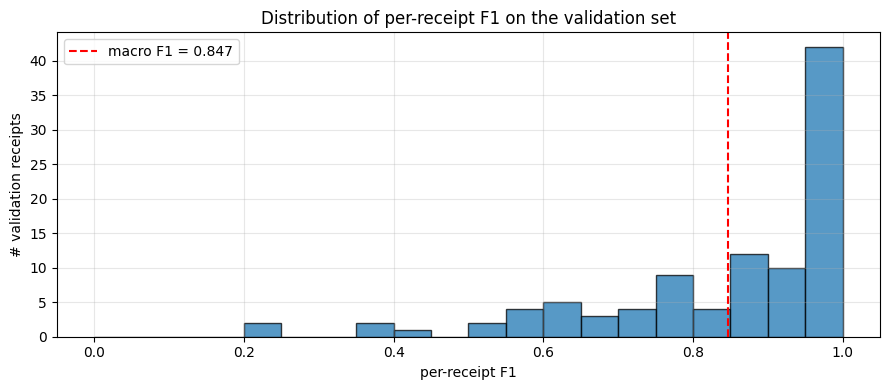

saved ./donut-cord-finetuned/f1_distribution.png

F1 stats:  min=0.218  median=0.909  mean=0.847  max=1.000
# perfect (F1 == 1.00): 39 / 100
# weak    (F1 <  0.50): 5 / 100


In [26]:
import statistics as _stats

plt.figure(figsize=(9, 4))
plt.hist(per_receipt_f1, bins=20, range=(0, 1), edgecolor="black", alpha=0.75)
plt.axvline(macro_f1, color="red", linestyle="--", label=f"macro F1 = {macro_f1:.3f}")
plt.xlabel("per-receipt F1")
plt.ylabel("# validation receipts")
plt.title("Distribution of per-receipt F1 on the validation set")
plt.legend()
plt.grid(True, alpha=0.3)
hist_path = os.path.join(Cfg.OUTPUT_DIR, "f1_distribution.png")
plt.tight_layout()
plt.savefig(hist_path, dpi=120)
plt.show()
print("saved", hist_path)

print(
    f"\nF1 stats:"
    f"  min={min(per_receipt_f1):.3f}"
    f"  median={_stats.median(per_receipt_f1):.3f}"
    f"  mean={_stats.mean(per_receipt_f1):.3f}"
    f"  max={max(per_receipt_f1):.3f}"
)
print(f"# perfect (F1 == 1.00): {sum(1 for x in per_receipt_f1 if x >= 0.999)} / {len(per_receipt_f1)}")
print(f"# weak    (F1 <  0.50): {sum(1 for x in per_receipt_f1 if x <  0.5)} / {len(per_receipt_f1)}")

In [27]:
# 10 worst validation predictions (lowest F1) — error analysis for the report.
worst_idxs = sorted(range(len(per_receipt_f1)), key=lambda i: per_receipt_f1[i])[:10]
print("=== 10 worst validation predictions (lowest F1) ===\n")
for rank, idx in enumerate(worst_idxs, 1):
    f1 = per_receipt_f1[idx]
    tp, fp, fn, _, _, _ = field_prf(all_gts[idx], all_preds[idx])
    print(f"--- rank {rank} | sample {idx} | F1={f1:.3f} | TP={tp} FP={fp} FN={fn} ---")
    print(f"GT  : {json.dumps(all_gts[idx], ensure_ascii=False)[:300]}")
    print(f"PRED: {json.dumps(all_preds[idx], ensure_ascii=False)[:300]}")
    print()

=== 10 worst validation predictions (lowest F1) ===

--- rank 1 | sample 93 | F1=0.218 | TP=6 FP=20 FN=23 ---
GT  : {"menu": [{"nm": "PAKET BER4", "cnt": "1", "price": "138,182", "sub": [{"nm": "BREAD N CHEESE DEL", "cnt": "1"}, {"nm": "BREAD N CHEESE DEL", "cnt": "1"}, {"nm": "CRABSTICK FUSILLI DEL", "cnt": "1"}, {"nm": "LIME SQUASH DEL", "cnt": "1"}, {"nm": "LIME SQUASH DEL", "cnt": "1"}, {"nm": "P/P SPICY TUNA
PRED: {"menu": [{"cnt": "1", "nm": "PAKET BER4", "price": "138,182"}, {"cnt": "1", "nm": "BREAD N CHEESE DEL"}, {"cnt": "1", "nm": "BREAD N CHEESE DEL"}, {"cnt": "1", "nm": "CRABSTICK FUSILLI DEL"}, {"cnt": "1", "nm": "LIME SQUASH DEL"}, {"cnt": "1", "nm": "LIME SQUASH DEL"}, {"cnt": "1", "nm": "P/P SPICY

--- rank 2 | sample 88 | F1=0.222 | TP=6 FP=22 FN=20 ---
GT  : {"menu": {"nm": "PAKET BER4 UP3", "cnt": "1", "price": "154,545", "sub": [{"nm": "BREAD N CHEESE DEL", "cnt": "1"}, {"nm": "TUNA DEL", "cnt": "1"}, {"nm": "CRABSTICK FUSILLI DEL", "cnt": "1"}, {"nm": "LEMON TEA H

## 16. Final scorecard — copy/paste into the report

Compact side-by-side table of all headline metrics on **validation** vs **test**. Updates `report_data.json` with the additional test_metrics + per-epoch fields.

In [28]:
print("=" * 70)
print("FINAL SCORECARD".center(70))
print("=" * 70)
print(f"\nModel       : Donut ({Cfg.BASE_MODEL})")
print(f"Dataset     : naver-clova-ix/cord-v2  (train={total_train}, val={total_val})")
print(f"Training    : {Cfg.EPOCHS} epochs   eff. batch = {Cfg.PER_DEVICE_BATCH * Cfg.GRAD_ACC}   lr = {Cfg.LR}")
print(f"Image size  : {Cfg.IMAGE_SIZE[0]} x {Cfg.IMAGE_SIZE[1]}")
print(f"Max decode  : {Cfg.MAX_LENGTH} tokens")


def _row(label, val_v, test_v=None, fmt="{:.4f}"):
    vs = fmt.format(val_v) if val_v is not None else "  --  "
    ts = fmt.format(test_v) if test_v is not None else "  --  "
    return f"  {label:<32s} {vs:>10s}    {ts:>10s}"


print("\n" + "-" * 70)
print(f"  {'METRIC':<32s} {'val':>10s}    {'test':>10s}")
print("-" * 70)

V = OVERALL_METRICS
T = TEST_METRICS or {}
print(_row("Exact-match accuracy",       V["exact_match_accuracy"],     T.get("exact_match_accuracy")))
print(_row("Field micro precision",      V["field_micro_precision"],    T.get("field_micro_precision")))
print(_row("Field micro recall",         V["field_micro_recall"],       T.get("field_micro_recall")))
print(_row("Field micro F1",             V["field_micro_f1"],           T.get("field_micro_f1")))
print(_row("Field macro F1",             V["field_macro_f1"],           T.get("field_macro_f1")))
print(_row("Normalized TED (lower=better)", V["mean_normalized_TED"],   T.get("mean_normalized_TED")))
print(_row("TED accuracy = 1 - nTED",    V["TED_accuracy"],             T.get("TED_accuracy")))
print(_row("Avg latency (ms)",           V["avg_latency_ms"],           T.get("avg_latency_ms"), "{:.0f}"))
print(_row("p95 latency (ms)",           V["p95_latency_ms"],           T.get("p95_latency_ms"), "{:.0f}"))
print("=" * 70)

# Append test metrics + per-epoch progression to the report file.
if TEST_METRICS is not None:
    report["test_metrics"] = TEST_METRICS
report["per_epoch"] = per_epoch
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print(f"\n(updated {report_path} with test_metrics + per_epoch)")

                           FINAL SCORECARD                            

Model       : Donut (naver-clova-ix/donut-base)
Dataset     : naver-clova-ix/cord-v2  (train=800, val=100)
Training    : 6 epochs   eff. batch = 4   lr = 3e-05
Image size  : 1280 x 960
Max decode  : 768 tokens

----------------------------------------------------------------------
  METRIC                                  val          test
----------------------------------------------------------------------
  Exact-match accuracy                 0.3900        0.2900
  Field micro precision                0.8304        0.8141
  Field micro recall                   0.8154        0.7909
  Field micro F1                       0.8228        0.8023
  Field macro F1                       0.8471        0.8165
  Normalized TED (lower=better)        0.4776        0.7015
  TED accuracy = 1 - nTED              0.5224        0.2985
  Avg latency (ms)                        373           387
  p95 latency (ms)                 